In [ ]:
import time
import copy
from pathlib import Path
import matplotlib.pyplot as plt
import math
import numpy as np
import pandas as pd
import torch
from matplotlib.lines import Line2D
from genkit import GaussianFlowLinear
from genkit.metrics import mse, msle_90, msle_99
from genkit._sampling import sample_gaussian, sample_scaled_isotropic_alpha_stable
from genkit.datasets import fetch_synthetic_data
from genkit.nn import MLPModel
from genkit.training import train
from genkit.visitor import CoreMetricsVisitor
from genkit.plotting import PRETTY_RCPARAMS


plt.rcParams.update(PRETTY_RCPARAMS)

In [11]:
def barron_loss(
    pred: torch.Tensor,
    target: torch.Tensor,
    alpha: float | torch.Tensor = 1.0,
    scale: float | torch.Tensor = 1.0,
    reduction: str = "mean",
    eps: float = 1e-12,
) -> torch.Tensor:
    """
    Barron robust loss (A General and Adaptive Robust Loss Function, Eq. 8).

    rho(x, alpha, c) =
        0.5 * (x / c)^2                                 if alpha == 2
        log(0.5 * (x / c)^2 + 1)                        if alpha == 0
        1 - exp(-0.5 * (x / c)^2)                       if alpha == -inf
        |alpha-2|/alpha * (((x/c)^2 / |alpha-2| + 1)^(alpha/2) - 1)  otherwise
    """
    if reduction not in {"none", "mean", "sum"}:
        raise ValueError(f"Invalid reduction: {reduction}")

    x = pred - target
    dtype = x.dtype
    device = x.device

    alpha = torch.as_tensor(alpha, dtype=dtype, device=device)
    scale = torch.as_tensor(scale, dtype=dtype, device=device).clamp_min(eps)

    z = (x / scale) ** 2

    loss_two = 0.5 * z
    loss_zero = torch.log1p(0.5 * z)
    loss_neginf = -torch.expm1(-0.5 * z)

    beta = torch.abs(alpha - 2.0).clamp_min(eps)
    loss_general = (beta / alpha) * (torch.pow(z / beta + 1.0, 0.5 * alpha) - 1.0)

    if alpha.ndim == 0:
        a = float(alpha.item())
        if math.isinf(a) and a < 0:
            loss = loss_neginf
        elif abs(a - 2.0) < 1e-6:
            loss = loss_two
        elif abs(a) < 1e-6:
            loss = loss_zero
        else:
            loss = loss_general
    else:
        is_two = torch.isclose(alpha, torch.tensor(2.0, dtype=dtype, device=device), atol=1e-6, rtol=0.0)
        is_zero = torch.isclose(alpha, torch.tensor(0.0, dtype=dtype, device=device), atol=1e-6, rtol=0.0)
        is_neginf = torch.isneginf(alpha)

        loss = torch.where(is_two, loss_two, loss_general)
        loss = torch.where(is_zero, loss_zero, loss)
        loss = torch.where(is_neginf, loss_neginf, loss)

    if reduction == "mean":
        return loss.mean()
    if reduction == "sum":
        return loss.sum()
    return loss


class AlphaStableSourceMixin:
    def __init__(self, *args, source_alpha: float = 1.5, **kwargs):
        super().__init__(*args, **kwargs)
        self._source_alpha = float(source_alpha)

    def _sample_source_default(self, n_samples: int) -> torch.Tensor:
        return sample_scaled_isotropic_alpha_stable(
            n_samples=n_samples,
            dim=self._dim,
            alpha=self._source_alpha,
            device=self._device,
            dtype=self._fdtype,
        )


class AlphaStableSourceGaussianFlowLinear(AlphaStableSourceMixin, GaussianFlowLinear):
    pass


class BarronLossMixin:
    def __init__(self, *args, alpha: float = 1.0, **kwargs):
        super().__init__(*args, **kwargs)
        self._alpha = float(alpha)

    def _loss_fn(self, pred: torch.Tensor, target: torch.Tensor, t: int):
        return barron_loss(pred, target, alpha=self._alpha, reduction="none")

    def _reduce(self, loss_values: torch.Tensor) -> torch.Tensor:
        return loss_values.mean()


def format_alpha_label(value: float) -> str:
    value = float(value)
    if value.is_integer():
        return str(int(value))
    return f"{value:g}"


def alpha_tag(value: float) -> str:
    label = format_alpha_label(value)
    return label.replace('-', 'neg').replace('.', 'p')


def build_model_specs(source_alpha, barron_alphas):
    sources = {"Gaussian": (GaussianFlowLinear, {}),
               "AlphaStable": (AlphaStableSourceGaussianFlowLinear, {"source_alpha": source_alpha}),
               }

    specs = []
    for source_distri, (source_cls, kwargs) in sources.items():
        for barron_alpha in barron_alphas:

            loss_name = rf"$\alpha = {format_alpha_label(barron_alpha)}$"
            name = f"{source_distri}BarronAlpha{alpha_tag(barron_alpha)}"
            cls = type(name, (BarronLossMixin, source_cls), {})
            kwargs["alpha"] = float(barron_alpha)
            spec = {"name": name,
                    "cls": cls,
                    "source_distri": source_distri,
                    "loss": loss_name,
                    "loss_alpha": float(barron_alpha),
                    "extra_kwargs": kwargs,
                    }

            specs.append(spec)
    return specs


def curve_style(spec, source_colors, loss_linestyles):
    color = source_colors[spec["source_distri"]]
    linestyle = loss_linestyles[float(spec["loss_alpha"])]
    return color, linestyle


def averaged_grad_curve(result, n_epochs, n_points=15):
    l_grad_var, l_loss = [], []
    for trial in result["trials"]:
        grad_var = np.asarray(trial["diagnostics"]["visitors"]["core"]["grad_variance_epoch"], dtype=float)
        loss = np.asarray(trial["diagnostics"]["visitors"]["core"]["training_loss"], dtype=float)
        l_grad_var.append(grad_var[::max(1, int(n_epochs / n_points))])
        l_loss.append(loss[::max(1, int(n_epochs / n_points))])
    return np.mean(np.stack(l_loss, axis=0), axis=0), np.mean(np.stack(l_grad_var, axis=0), axis=0)


In [ ]:
dim = 2
stable_alpha_data = 1.8
n_samples = 2**12

stable_alpha_model = 1.8
barron_alphas = [2.0, 1.0, 0.0, -1000.0]
n_steps = 2**7
batch_size = 2**8
n_epochs = 2**10
lr = 1e-3
depth = 1
width = 2**6
n_trials = 3
num_workers = 0

source_order = ["Gaussian", "AlphaStable"]
loss_order = [f"$\\alpha = {format_alpha_label(alpha)}$" for alpha in barron_alphas]

device = "cuda" if torch.cuda.is_available() else "cpu"
fdtype = torch.float32
idtype = torch.int32

source_colors = {"Gaussian": "tab:blue",
                "AlphaStable": "tab:red",
                }

loss_linestyles = {2.0: "solid",
                   1.0: "dashed",
                   0.0: "dashdot",
                   -1000.0: "dotted",
                }


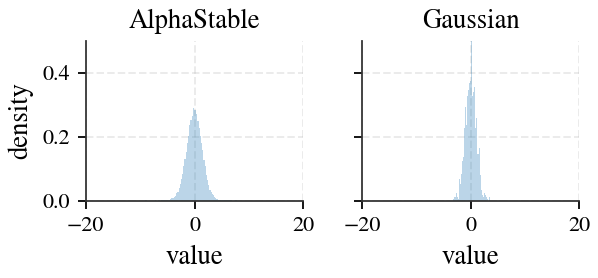

In [4]:
preview_n = 50_000

preview_samples = {"AlphaStable": sample_scaled_isotropic_alpha_stable(n_samples=preview_n, dim=1, alpha=stable_alpha_data, device="cpu", dtype=torch.float32).squeeze(-1).cpu().numpy(),
                   "Gaussian": sample_gaussian(n_samples=preview_n, dim=1, device="cpu", dtype=torch.float32).squeeze(-1).cpu().numpy(),
                   }

fig, axis = plt.subplots(1, len(preview_samples), figsize=(4.0, 2.0), squeeze=False, sharex=True, sharey=True)
for ax, (name, values) in zip(axis.flat, preview_samples.items()):
    ax.hist(values, bins=int(preview_n / 20), density=True, alpha=0.3, color="tab:blue", label="hist")
    ax.set_xlim(-20, 20)
    ax.set_ylim(0, 0.5)
    ax.set_title(name)

axis[0, 0].set_xlabel("value")
axis[0, 1].set_xlabel("value")
axis[0, 0].set_ylabel("density")

fig.tight_layout()


In [ ]:
model_specs = build_model_specs(stable_alpha_model, barron_alphas)

x_train, _, x_ref = fetch_synthetic_data("alpha_stable", alpha=stable_alpha_data, n_samples=n_samples,
                                         dim=dim, device=device, dtype=fdtype)

kwargs = dict(target_data=x_train, batch_size=batch_size, n_epochs=n_epochs,
              lr=lr, device=device, num_workers=num_workers)
net_kwargs = dict(width=width, depth=depth)


In [ ]:
raw_results = {}
total_runs = len(model_specs) * n_trials
run_idx = 0

for spec in model_specs:
    trials = []
    for trial_idx in range(n_trials):
        run_idx += 1
        extra_kwargs = dict(spec["extra_kwargs"])
        net = MLPModel(dim=dim, **net_kwargs).to(device=device, dtype=fdtype)
        generator = spec["cls"](net=net, dim=dim, n_steps=n_steps, device=device, fdtype=fdtype, idtype=idtype, **extra_kwargs)
        kwargs["generative_model"] = generator
        kwargs["visitors"] = [CoreMetricsVisitor()]

        t0 = time.time()
        print(f"[{run_idx:02d} / {total_runs:02d}] {spec['name']} trial {trial_idx + 1}/{n_trials}: Training...", end="")
        generator, diagnostics = train(**kwargs)
        print(f"Done (in {time.time() - t0:.1f} s).")

        trials.append({
            "generator": generator,
            "diagnostics": diagnostics,
            "extra_kwargs": extra_kwargs,
        })

    raw_results[spec["name"]] = {
        "meta": {k: spec[k] for k in ("name", "source_distri", "loss", "loss_alpha")},
        "trials": trials,
    }


[01 / 24] GaussianBarronAlpha2 trial 1/3: Training...Done (in 81.1 s).
[02 / 24] GaussianBarronAlpha2 trial 2/3: Training...Done (in 79.5 s).
[03 / 24] GaussianBarronAlpha2 trial 3/3: Training...Done (in 79.3 s).
[04 / 24] GaussianBarronAlpha1 trial 1/3: Training...Done (in 97.6 s).
[05 / 24] GaussianBarronAlpha1 trial 2/3: Training...Done (in 89.7 s).
[06 / 24] GaussianBarronAlpha1 trial 3/3: Training...Done (in 91.4 s).
[07 / 24] GaussianBarronAlpha0 trial 1/3: Training...Done (in 96.1 s).
[08 / 24] GaussianBarronAlpha0 trial 2/3: Training...Done (in 75.6 s).
[09 / 24] GaussianBarronAlpha0 trial 3/3: Training...Done (in 80.0 s).
[10 / 24] GaussianBarronAlphaneg1000 trial 1/3: Training...Done (in 77.7 s).
[11 / 24] GaussianBarronAlphaneg1000 trial 2/3: Training...Done (in 73.2 s).
[12 / 24] GaussianBarronAlphaneg1000 trial 3/3: Training...Done (in 75.3 s).
[13 / 24] AlphaStableBarronAlpha2 trial 1/3: Training...Done (in 77.0 s).
[14 / 24] AlphaStableBarronAlpha2 trial 2/3: Training...

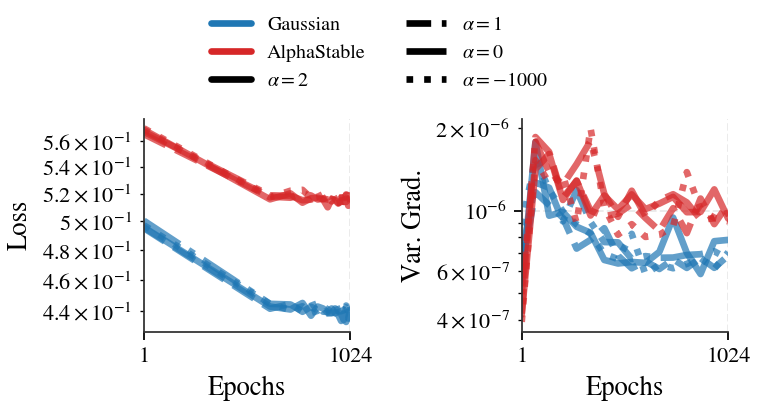

In [29]:
results = copy.deepcopy(raw_results)

lw = 3.0

fig, axis = plt.subplots(1, 2, figsize=(5.0, 2.5), squeeze=False)

for spec in model_specs:
    avg_loss, avg_grad_var = averaged_grad_curve(results[spec["name"]], n_epochs=n_epochs)
    tt = np.linspace(1, n_epochs, len(avg_loss), dtype=int)
    color, linestyle = curve_style(spec, source_colors=source_colors, loss_linestyles=loss_linestyles)
    axis[0, 0].plot(tt, avg_loss, color=color, ls=linestyle, lw=lw, alpha=0.7)
    axis[0, 1].plot(tt, avg_grad_var, color=color, ls=linestyle, lw=lw, alpha=0.7)

axis[0, 0].set_xscale("log")
axis[0, 0].set_yscale("log")
axis[0, 0].set_xlim(1, n_epochs)
axis[0, 0].set_xticks([1, n_epochs], ["1", f"{n_epochs}"])
axis[0, 0].set_xlabel("Epochs")
axis[0, 0].set_ylabel("Loss")

axis[0, 1].set_yscale("log")
axis[0, 1].set_xlim(1, n_epochs)
axis[0, 1].set_xticks([1, n_epochs], ["1", f"{n_epochs}"])
axis[0, 1].set_xlabel("Epochs")
axis[0, 1].set_ylabel("Var. Grad.")

legend_handles = [Line2D([0], [0], color=color, lw=lw, label=source_name)
                  for source_name, color in source_colors.items()]
legend_handles += [Line2D([0], [0], color="black", lw=lw, ls=loss_linestyles[alpha_value], label=rf"$\alpha = {format_alpha_label(alpha_value)}$")
                   for alpha_value in barron_alphas]

fig.legend(legend_handles, [handle.get_label() for handle in legend_handles],
           loc="upper center", bbox_to_anchor=(0.5, 1.08), ncol=2, frameon=False,
           fontsize=9)

fig.tight_layout(rect=(0, 0, 1.0, 0.85))


In [1]:
results = copy.deepcopy(raw_results)

rows = []
for spec in model_specs:
    result = results[spec["name"]]
    trial_metrics = []
    for trial_idx, trial in enumerate(result["trials"], start=1):
        with torch.no_grad():
            x_gen = trial["generator"].sample(len(x_ref))

        trial_metrics.append({
            "trial": trial_idx,
            "test-MSE": float(mse(x_gen, x_ref)),
            "test-MSLE90": float(msle_90(x_gen, x_ref)),
            "test-MSLE99": float(msle_99(x_gen, x_ref)),
        })

    row = {
        "source_distri": spec["source_distri"],
        "loss": spec["loss"],
        "loss_alpha": spec["loss_alpha"],
        "n_trials": len(trial_metrics),
    }
    for metric_name in ("test-MSE", "test-MSLE90", "test-MSLE99"):
        values = [trial_metric[metric_name] for trial_metric in trial_metrics]
        row[metric_name] = float(np.mean(values))
        row[f"{metric_name}-std"] = float(np.std(values))
    rows.append(row)

df = pd.DataFrame(rows)
df["source_distri"] = pd.Categorical(df["source_distri"], categories=source_order, ordered=True)
df["loss"] = pd.Categorical(df["loss"], categories=loss_order, ordered=True)
df = df.sort_values(["source_distri", "loss_alpha"]).reset_index(drop=True)

tables = {}
caption_items = {"(a) Averaged test-MSE": r"test-$\mathrm{MSE}$",
                 "(b) Averaged test-MSLE90": r"test-$\mathrm{MSLE}(90)$",
                 "(c) Averaged test-MSLE99": r"test-$\mathrm{MSLE}(99)$",
                 }
for caption, metric_name in caption_items.items():
    table_df = df.pivot_table(index="source_distri", columns="loss", values=metric_name,
                              aggfunc="mean", observed=False)
    table_df = table_df.reindex(index=source_order, columns=loss_order)
    tables[caption] = table_df

fig, axis = plt.subplots(3, 1, figsize=(3.5, 3.5), squeeze=False)

for i, (caption, table_df) in enumerate(tables.items()):
    axis[i, 0].axis("off")
    formatted = table_df.map(lambda x: "-" if pd.isna(x) else f"{x:.2e}")
    row_min_mask = table_df.eq(table_df.min(axis=1), axis=0)
    table_min_mask = table_df.eq(table_df.min().min())

    table = axis[i, 0].table(
        cellText=formatted.values,
        rowLabels=formatted.index,
        colLabels=formatted.columns,
        cellLoc="center",
        rowLoc="center",
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1.2, 1.6)

    for (row, col), cell in table.get_celld().items():
        cell.set_linewidth(0.5)
        cell.set_text_props(alpha=0.7)
        if row == 0 or col == -1:
            cell.set_text_props(weight="bold", alpha=1.0)
        elif row > 0 and col >= 0 and row_min_mask.iloc[row - 1, col]:
            cell.set_text_props(alpha=1.0)
            if table_min_mask.iloc[row - 1, col]:
                cell.set_text_props(weight="bold", alpha=1.0)

    axis[i, 0].text(0.5, -0.05, caption, transform=axis[i, 0].transAxes,
                    ha="center", va="top", fontsize=8)

fig.tight_layout()


NameError: name 'copy' is not defined